In [1]:
import os
import uuid
import numpy as np
import rasterio
from xdem import DEM
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import io
import base64

In [2]:
def compute_dem_difference(path1: str, path2: str):
    """Завантажує DEM, обчислює різницю та повертає масив і DEM-профіль."""
    dem1 = DEM(path1)
    dem2 = DEM(path2)

    difference = dem2.data - dem1.data
    return difference, dem1  # xDEM-об’єкт містить profile

In [3]:
def save_temp_diff_as_cog(diff_array: np.ndarray, reference_dem: DEM, prefix="diff_") -> str:
    """Зберігає різницю як COG-файл у /tmp/ і повертає шлях."""
    filename = f"{prefix}{uuid.uuid4().hex}.tif"
    out_path = os.path.join("/tmp", filename)

    profile = reference_dem.profile
    profile.update({
        "driver": "COG",
        "dtype": "float32",
        "count": 1,
        "compress": "deflate"
    })

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(diff_array.astype("float32"), 1)

    return out_path

In [4]:
def calculate_error_statistics(diff_array: np.ndarray):
    """Повертає науково обґрунтовані статистики різниці DEM."""
    valid = diff_array[~np.isnan(diff_array)]

    return {
        "count": int(valid.size),
        "mean_error": float(np.mean(valid)),
        "median_error": float(np.median(valid)),
        "std_dev": float(np.std(valid)),
        "rmse": float(np.sqrt(np.mean(valid ** 2))),
        "min": float(np.min(valid)),
        "max": float(np.max(valid)),
        "skewness": float(skew(valid)),
        "kurtosis": float(kurtosis(valid))
    }

In [5]:

def plot_heatmap(diff_array: np.ndarray, vmin=-10, vmax=10):
    """Повертає heatmap як base64-картинку."""
    fig, ax = plt.subplots(figsize=(8, 6))
    img = ax.imshow(diff_array, cmap="RdBu", vmin=vmin, vmax=vmax)
    fig.colorbar(img, ax=ax, label="Різниця висоти (м)")
    ax.set_title("DEM Height Difference")
    return fig_to_base64(fig)


In [6]:

def plot_histogram(diff_array: np.ndarray, bins=50):
    """Гістограма похибок."""
    valid = diff_array[~np.isnan(diff_array)]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(valid, bins=bins, color="skyblue", edgecolor="black")
    ax.set_title("Histogram of Elevation Errors")
    ax.set_xlabel("Error (m)")
    ax.set_ylabel("Frequency")
    return fig_to_base64(fig)

In [7]:
def fig_to_base64(fig):
    """Конвертує matplotlib figure у base64 для Dash."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode("ascii")
    plt.close(fig)
    return f"data:image/png;base64,{img_base64}"

In [8]:
path1 = "data/COG/dem/fab_dem_cog.tif"
path2 = "data/COG/dem/copernicus_dem_cog.tif"

# Обчислення різниці
diff_array, reference_dem = compute_dem_difference(path1, path2)

# Збереження як COG у /tmp/
temp_path = save_temp_diff_as_cog(diff_array, reference_dem)

print("📁 Файл збережено у:", temp_path)


📁 Файл збережено у: /tmp/diff_c84f296b384c47579cb1c33a6a638c85.tif


In [9]:
stats = calculate_error_statistics(diff_array)

# Вивід у зручному вигляді
for k, v in stats.items():
    print(f"{k}: {v:.4f}")


count: 2313822.0000
mean_error: 8.6944
median_error: -9999.0000
std_dev: 5.9484
rmse: 10.5345
min: -16.5530
max: 32.6548
skewness: 0.0488
kurtosis: -1.0786


/home/niko/miniforge3/envs/geohydroai/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


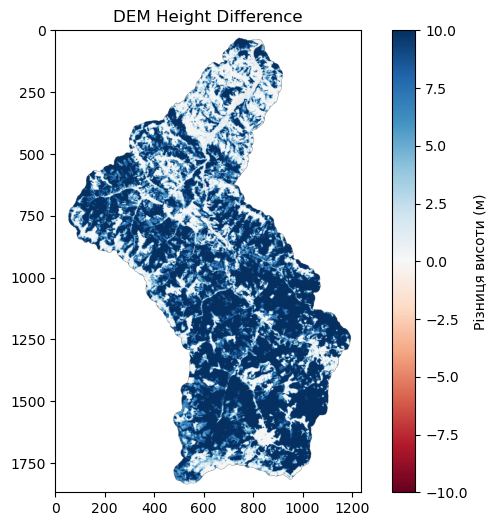

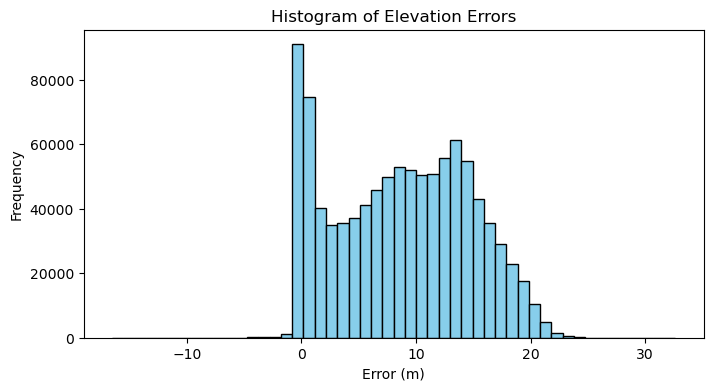

In [10]:
from IPython.display import Image, display

# Показати heatmap
display(Image(data=base64.b64decode(plot_heatmap(diff_array).split(',')[1])))

# Показати гістограму
display(Image(data=base64.b64decode(plot_histogram(diff_array).split(',')[1])))


In [11]:
def full_dem_diff_analysis(path1, path2):
    diff, ref = compute_dem_difference(path1, path2)
    stats = calculate_error_statistics(diff)
    out_path = save_temp_diff_as_cog(diff, ref)
    print("📁 Збережено у:", out_path)
    print("📈 Статистика:")
    for k, v in stats.items():
        print(f"{k}: {v:.4f}")
    display(Image(data=base64.b64decode(plot_heatmap(diff).split(',')[1])))
    display(Image(data=base64.b64decode(plot_histogram(diff).split(',')[1])))


/home/niko/miniforge3/envs/geohydroai/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


📁 Збережено у: /tmp/diff_916cf8fb80bf4014853e8048447bca1f.tif
📈 Статистика:
count: 2313822.0000
mean_error: 8.6944
median_error: -9999.0000
std_dev: 5.9484
rmse: 10.5345
min: -16.5530
max: 32.6548
skewness: 0.0488
kurtosis: -1.0786


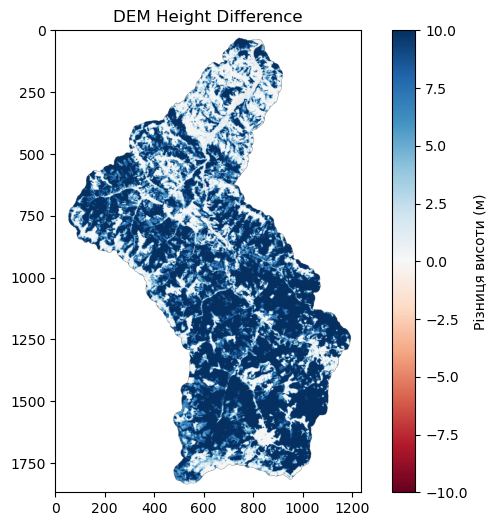

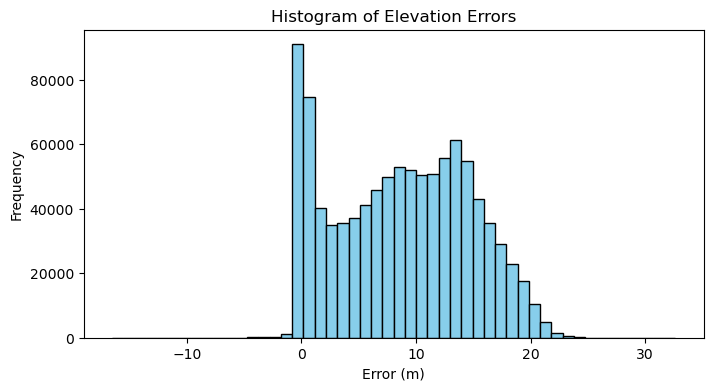

In [12]:
full_dem_diff_analysis(path1, path2)

In [13]:
from PIL import Image
img = Image.new('RGBA', (1, 1), (255, 255, 255, 0))
img.save('assets/transparent.png')